# Import Library

In [30]:
import os
import time
import numpy as np
import plotly.graph_objects as go
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from google import genai

# Load API KEY

In [31]:
load_dotenv()
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
client=genai.Client(api_key=GEMINI_API_KEY)

# Load Docs

In [32]:
def load_documents():
    docs={}
    for fname in ['D1.md','D2.md','D3.md']:
        with open(os.path.join('dokumen',fname),encoding='utf-8') as f:
            docs[fname[:-3]]=f.read().strip()
    return docs
DOCS=load_documents()

# Definisi Fungsi

embedding menggunakan model gemini-embedding-001

In [33]:
import hashlib
from typing import Iterable
from httpx import ReadError, ConnectError, TimeoutException

def _local_fallback_embedding(text: str, dim: int = 256) -> list[float]:
    # Deterministic fallback embedding based on text hash.
    vec = np.zeros(dim, dtype=np.float32)
    tokens: Iterable[str] = text.lower().split()
    for tok in tokens:
        h = int(hashlib.sha256(tok.encode("utf-8")).hexdigest(), 16)
        vec[h % dim] += 1.0
    norm = np.linalg.norm(vec)
    if norm == 0:
        return vec.tolist()
    return (vec / norm).tolist()

def get_embedding(text: str, retries: int = 4, base_delay: float = 1.0):
    last_exc = None
    for attempt in range(retries):
        try:
            resp = client.models.embed_content(
                model="gemini-embedding-001",
                contents=text,
            )
            return resp.embeddings[0].values
        except (ReadError, ConnectError, TimeoutException) as exc:
            last_exc = exc
            if attempt < retries - 1:
                time.sleep(base_delay * (2 ** attempt))
            continue

    print(f"Warning: Gemini embedding gagal setelah {retries} percobaan ({last_exc}). Pakai fallback lokal.")
    return _local_fallback_embedding(text)

def cosine_sim(a, b):
    a, b = np.array(a), np.array(b)
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom == 0:
        return 0.0
    return float(np.dot(a, b) / denom)

# Set Query

In [34]:
query='What time do I leave for school?'

# Vector Search

In [35]:
doc_vecs = {}
for k, v in DOCS.items():
    try:
        doc_vecs[k] = get_embedding(v)
    except Exception as exc:
        print(f"Skip dokumen {k} karena error: {exc}")

if not doc_vecs:
    raise RuntimeError("Tidak ada embedding dokumen yang berhasil dibuat.")

q_vec = get_embedding(query)
# print(f"Query embedding: {q_vec}")

scores = {k: cosine_sim(q_vec, v) for k, v in doc_vecs.items()}
best = max(scores, key=scores.get)
print(f"Scores: {scores}")
print(f"Best match: {best}")

Scores: {'D1': 0.6863587302695408, 'D2': 0.5241984543891248, 'D3': 0.46450598695206463}
Best match: D1


In [36]:
def answer_query(
    query: str,
    best_key: str,
    scores: dict[str, float],
    docs: dict[str, str],
    metric: str = "cosine similarity",
) -> dict:
    doc_text = docs[best_key]
    scores_text = "\n".join([f"- {k}: {v:.4f}" for k, v in scores.items()])
    prompt = (
        f"You are a semantic Question Answering system.\n"
        f'A user asked: "{query}"\n\n'
        f"Based on {metric}, the best matching document is {best_key}.\n"
        f"Scores:\n{scores_text}\n\n"
        f"Content of {best_key}:\n{doc_text}\n\n"
        "Answer the query using ONLY the content above.\n"
        "Format your answer as:\n"
        f"ANSWER: [direct answer based on {best_key}]\n"
        "SNIPPET: [1 relevant sentence from the document]\n"
        "REASON: [why this document is the best match in 1 sentence]"
    )
    resp = client.models.generate_content(
        model="gemini-3.1-flash-lite",
        contents=prompt,
    )
    lines = resp.text.strip().split("\n")
    result = {"answer": "", "snippet": "", "reason": ""}
    current = ""
    for line in lines:
        if line.startswith("ANSWER:"):
            current = "answer"
            result["answer"] = line.replace("ANSWER:", "").strip()
        elif line.startswith("SNIPPET:"):
            current = "snippet"
            result["snippet"] = line.replace("SNIPPET:", "").strip()
        elif line.startswith("REASON:"):
            current = "reason"
            result["reason"] = line.replace("REASON:", "").strip()
        elif current == "answer" and line.strip():
            result["answer"] += " " + line.strip()
        elif current == "reason" and line.strip():
            result["reason"] += " " + line.strip()
    return result



In [39]:
rag_result = answer_query(
    query=query,
    best_key=best,
    scores=scores,
    docs=DOCS,
    metric="cosine similarity",
)

print(f"Query : {query}")
print("ANSWER:", rag_result.get("answer", ""))
print("SNIPPET:", rag_result.get("snippet", ""))
print("REASON:", rag_result.get("reason", ""))

Query : What time do I leave for school?
ANSWER: You leave for school at around 6:30 PM.
SNIPPET: I always leave home at around 6:30 PM .
REASON: Document D1 is the best match because it directly addresses the time of departure, achieving the highest cosine similarity score among the available documents.


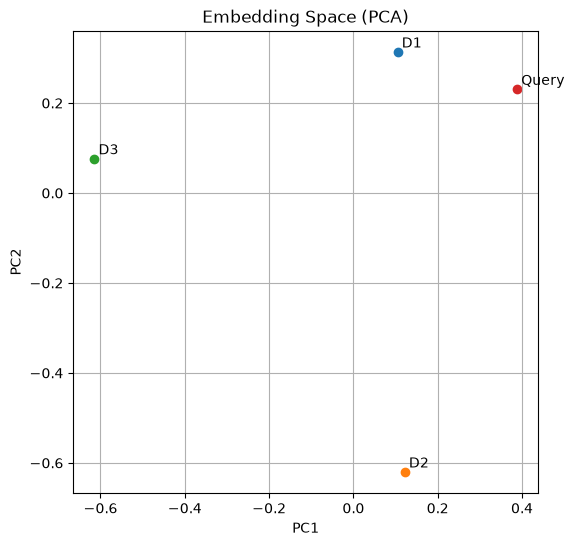

In [38]:
vectors = np.array([
    doc_vecs["D1"],
    doc_vecs["D2"],
    doc_vecs["D3"],
    q_vec
])

labels = ["D1","D2","D3","Query"]

pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

plt.figure(figsize=(6,6))

for i,label in enumerate(labels):
    plt.scatter(coords[i,0], coords[i,1])
    plt.text(coords[i,0]+0.01, coords[i,1]+0.01,label)

plt.title("Embedding Space (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()